<H1> 1) Dataset Statistics :</H1>


In [ ]:
import pandas as pd
import re

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/datasets/sharing dataset file.csv')
# 1) قراءة الملف

# التأكد أن الأعمدة نصية
df["الجملة"] = df["الجملة"].astype(str)
df["المتحدث"] = df["المتحدث"].astype(str)

# 2) Total utterances
total_utterances = len(df)

# 3) Total words + Avg. words/utterance
df["عدد_الكلمات"] = df["الجملة"].apply(lambda x: len(x.split()))
total_words = int(df["عدد_الكلمات"].sum())
avg_words_per_utterance = df["عدد_الكلمات"].mean()

# 4) Teacher utterances
# م = معلم
teacher_labels = {"م", "معلم", "معلمة", "teacher", "t"}
teacher_utterances = df[df["المتحدث"].str.strip().isin(teacher_labels)]
num_teacher_utterances = len(teacher_utterances)

# 5) Student utterances
# س / ط = طالب
student_labels = {"س", "ط", "طالب", "طالبة", "student", "s"}
student_utterances = df[df["المتحدث"].str.strip().isin(student_labels)]
num_student_utterances = len(student_utterances)

# 6) Utterances with math
math_pattern = r"[0-9٠-٩+\-*/=<>^×÷٪%]"
df["يحتوي_رياضيات"] = df["الجملة"].apply(
    lambda x: bool(re.search(math_pattern, x))
)
utterances_with_math = int(df["يحتوي_رياضيات"].sum())

# 7) النتائج النهائية
summary = {
    "Total utterances": total_utterances,
    "Total words": total_words,
    "Avg. words / utterance": round(avg_words_per_utterance, 2),
    "Teacher utterances": num_teacher_utterances,
    "Student utterances": num_student_utterances,
    "Utterances with math": utterances_with_math,
}

summary


Mounted at /content/drive


{'Total utterances': 3619,
 'Total words': 25693,
 'Avg. words / utterance': np.float64(7.1),
 'Teacher utterances': 1721,
 'Student utterances': 99,
 'Utterances with math': 445}

In [ ]:
summary = {
    "Total utterances": int(total_utterances),
    "Total words": int(total_words),
    "Avg. words / utterance": float(round(avg_words_per_utterance, 2)),
    "Teacher utterances": int(num_teacher_utterances),
    "Student utterances": int(num_student_utterances),
    "Utterances with math": int(utterances_with_math),
}
summary


{'Total utterances': 3619,
 'Total words': 25693,
 'Avg. words / utterance': 7.1,
 'Teacher utterances': 1721,
 'Student utterances': 99,
 'Utterances with math': 445}

In [ ]:

import pandas as pd
import re

from google.colab import drive
drive.mount('/content/drive')
# 1) قراءة الملف
df2 = pd.read_csv("/content/drive/MyDrive/datasets/Dataset_File.csv")

# تأكيد الأعمدة النصية
df2["Sentence"] = df2["Sentence"].astype(str)
df2["Speaker"] = df2["Speaker"].astype(str)

# 2) Total utterances
total_utterances = len(df2)

# 3) Total words + Avg. words / utterance
df2["word_count"] = df2["Sentence"].apply(lambda x: len(x.split()))
total_words = int(df2["word_count"].sum())
avg_words = float(round(df2["word_count"].mean(), 2))

# 4) Teacher utterances (T)
teacher_utterances = df2[df2["Speaker"].str.strip() == "T"]
num_teacher_utterances = len(teacher_utterances)

# 5) Student utterances (S)
student_utterances = df2[df2["Speaker"].str.strip() == "S"]
num_student_utterances = len(student_utterances)

# 6) Utterances with math
math_pattern = r"[0-9+\-*/=<>^×÷٪%]|(area|perimeter|circumference|math|circle|rectangle)"
df2["has_math"] = df2["Sentence"].str.lower().apply(
    lambda x: bool(re.search(math_pattern, x))
)

utterances_with_math = int(df2["has_math"].sum())

# 7) النتائج النهائية
summary = {
    "Total utterances": total_utterances,
    "Total words": total_words,
    "Avg. words / utterance": avg_words,
    "Teacher utterances": num_teacher_utterances,
    "Student utterances": num_student_utterances,
    "Utterances with math": utterances_with_math,
}

summary


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


{'Total utterances': 3621,
 'Total words': 32171,
 'Avg. words / utterance': 8.88,
 'Teacher utterances': 1722,
 'Student utterances': 99,
 'Utterances with math': 602}

<H1> 2) First method :</H1>

In [ ]:
# ============================================================
# Setup (Py3.12 / CPU-safe)
# ============================================================
!pip -q install torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip -q install transformers==4.44.2 pandas numpy matplotlib scikit-learn pyarabic
!pip install arabic-reshaper python-bidi

import os, re, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple
from collections import Counter, defaultdict
from pyarabic.araby import strip_tashkeel, strip_tatweel, normalize_hamza
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Checks if a GPU (CUDA) is available.
DEVICE = 0 if torch.cuda.is_available() else -1
print("CUDA available:", torch.cuda.is_available())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 11.7 MB/s eta 0:00:00
CUDA available: True


In [ ]:
import arabic_reshaper
from bidi.algorithm import get_display

# for making the arabic text appiar correct
def ar(text):
    reshaped = arabic_reshaper.reshape(text)   # توصيل الحروف
    return get_display(reshaped)               # عكس الاتجاه لعرض RTL

# اختيار خط يدعم العربية
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False


In [ ]:
# the column in dataset contains the Arabic sentences.
TEXT_COL = "الجملة"

# Sentiment model (supports Arabic):
SENT_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment" ## detect sentiment (positive / neutral / negative)
ZS_MODEL   = "joeddav/xlm-roberta-large-xnli"   # Checks which category (talk move) best matches the meaning of the sentence


In [ ]:
# ============================================================
# Utilities: Arabic normalization & tokenization
# ============================================================

#defines all punctuation marks (Arabic and English)
AR_PUNCT = r"""[.\,\!\?\:\;\(\)\[\]\{\}\/\\\-\–\—\_\"\'\“\”\‘\’\«\»\:\،\؛\؟]"""

TOKEN_SPLIT_RE = re.compile(rf"\s+|{AR_PUNCT}") #It turns the string "\s+|{AR_PUNCT}" into a compiled regex object

# defines a set of Arabic stopwords,
AR_STOP = set("""
في على عن من إلى و أو ثم لأن إن أن كان تكون تكونوا كانوا التي الذي الذين هذا هذه ذلك هناك مع أيضًا ايضا حيث كما ما لا نعم هل من خلال إذا اذا قد كل أي اي ذاك تلك لدي لدى عند جدا جداً فقط كلما بين حتى بعد قبل فوق تحت منذ لماذا كيف ماذا متى
""".split())

def normalize_ar(text: str) -> str:
    if not isinstance(text, str):
        text = str(text or "")
    t = strip_tashkeel(text)   # remove harakat
    t = strip_tatweel(t)       # remove ـ
    # 1) unify alif forms: أ إ آ ا → ا
    t = re.sub(r"[إأآا]", "ا", t)
    # 2) unify yaa: ى → ي
    t = t.replace("ى", "ي")
    t = re.sub(r"\s+", " ", t).strip()
    return t


#Splits the normalized text into tokens (words) using the regex above.
#Removes empty strings caused by extra spaces or punctuation.
# tokenize_ar("أنا أحب التعلم!") → ['أنا', 'أحب', 'التعلم']
def tokenize_ar(text_norm: str) -> List[str]:
    return [tok for tok in TOKEN_SPLIT_RE.split(text_norm) if tok] # “ TOKEN_SPLIT_RE.split(text_norm) Split the text into parts wherever there’s punctuation or whitespace.”

# Filters out: Stopwords (AR_STOP) & Numbers & Very short tokens (like single letters)
# remove_stop(['أنا', 'أحب', 'في', 'التعلم', '3']) → ['أحب', 'التعلم']

#def remove_stop(tokens: List[str]) -> List[str]:
    #return [t for t in tokens if t not in AR_STOP and not t.isdigit() and len(t) > 1]
AR_ONLY_RE = re.compile(r"^[\u0600-\u06FF]+$")  # كلمة عربية فقط

def remove_stop(tokens: List[str]) -> List[str]:
    return [
        t for t in tokens
        if t
        and t not in AR_STOP
        and not t.isdigit()
        and len(t) > 1
        and AR_ONLY_RE.match(t)
    ]

In [ ]:
# ============================================================
# Stage 1) PRE-PROCESSING
#   - Text Pre-Processing
#   - Token Pre-Processing
# ============================================================

# 1- cleaning
# Takes a Pandas Series (Sentence_AR) --> Fills any missing values with empty strings --> Converts everything to string type --> Applies earlier function normalize_ar to every cell
class TextPreProcessor:
    def transform(self, s: pd.Series) -> pd.Series:
        return s.fillna("").astype(str).map(normalize_ar)

# 2- tokenization
# It tokenizes each sentence (splits into words) & removes stopwords & counting how many tokens each has.
class TokenPreProcessor:
    def transform(self, s: pd.Series) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series]:
        toks = s.map(tokenize_ar)
        toks_ns = toks.map(remove_stop)
        n_tok = toks.map(len)
        n_tok_ns = toks_ns.map(len)
        return toks, toks_ns, n_tok, n_tok_ns

# the main pipeline class that combines the two smaller ones.
class PreProcessing:
    # 1- TextPreProcessor (cleaning) & 2- TokenPreProcessor (tokenization)
    def __init__(self):
        self.text_proc  = TextPreProcessor()
        self.token_proc = TokenPreProcessor()
    # The .run() method:
    def run(self, df: pd.DataFrame, text_col: str) -> pd.DataFrame:
        df = df.copy()
        df["text_norm"] = self.text_proc.transform(df[text_col])
        df["tokens"], df["tokens_nostop"], df["n_tokens"], df["n_tokens_nostop"] = \
            self.token_proc.transform(df["text_norm"])
        return df


In [ ]:
# ============================================================
# Stage 2 — Annotation
# ============================================================

from transformers import pipeline

ZS_MODEL   = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"        # zero-shot (Arabic-capable)
SENT_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"  # sentiment (pos/neu/neg)

TALKMOVE_LABELS_AR = [
    "سؤال تفسيري", "توجيه", "تشجيع",
    "تغذية راجعة", "طلب توضيح", "إعادة صياغة", "دعوة للمشاركة"
]


class Annotator:
    def __init__(self, device: int = DEVICE, batch_size: int = 32, max_chars: int = 512):
        self.batch_size = batch_size
        self.max_chars  = max_chars
        self.zs   = pipeline("zero-shot-classification", model=ZS_MODEL, tokenizer=ZS_MODEL, device=device)
        self.sent = pipeline("sentiment-analysis", model=SENT_MODEL, tokenizer=SENT_MODEL, device=device)

    def run(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # Ensure text_norm exists (from Stage 1)
        assert "text_norm" in df.columns, "Stage 1 must run before Stage 2 (missing 'text_norm')."
        df["text_norm"] = df["text_norm"].astype(str).str.slice(0, self.max_chars)

        texts = df["text_norm"].tolist()
        tm_labels, tm_scores, sent_labels, sent_scores = [], [], [], []

        for i in range(0, len(texts), self.batch_size):
            chunk = texts[i:i+self.batch_size]

            # Zero-shot talk move AR
            zres = self.zs(chunk, TALKMOVE_LABELS_AR, multi_label=False)
            # Sentiment
            sres = self.sent(chunk, truncation=True)

            # Collect
            for r in zres:
                tm_labels.append(r["labels"][0])
                tm_scores.append(float(r["scores"][0]))
            for r in sres:
                sent_labels.append(r["label"])
                sent_scores.append(float(r["score"]))

        df["talk_move"]       = tm_labels
        df["talk_move_score"] = tm_scores
        df["sentiment"]       = sent_labels
        df["sentiment_score"] = sent_scores

        # question mark in Arabic/Latin
        df["is_question"] = df["text_norm"].str.contains(r"[؟\?]", regex=True)

        return df


In [ ]:
# ============================================================
# Stage 3) ANALYZERS
#   - Qualitative Analyzer
#   - Quantitative Analyzer
#   - Lexical Analyzer
#   - Temporal Analyzer
#   - GPT Conversation Analyzer (lightweight, extractive)
# ============================================================

class QualitativeAnalyzer:

    def sample_by_label(self, df: pd.DataFrame, label_col: str, k: int = 3) -> Dict[str, pd.DataFrame]:
        out = {}
        for lab in df[label_col].dropna().unique():
            out[lab] = df[df[label_col]==lab].sample(min(k, (df[label_col]==lab).sum()), random_state=42)
        return out

    def sample_pairs_teacher_student(self, df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
        ex = []
        for _, row in df.sort_values("turn_id").iterrows():
            ex.append(row)
        ex = pd.DataFrame(ex)
        return ex.head(k*2)

    def print_examples(
        self,
        df: pd.DataFrame,
        speaker_column: str,
        text_column: str,
        feature_column: str,
        feature_value: Optional[str] = None,
        max_num_examples: int = 3,
        show_k_previous_lines: int = 0,
        show_k_next_lines: int = 0,
    ) -> None:


        df_all = df[df["role"].isin(["المعلم", "الطالب"])].copy()
        df_all = df_all.sort_values("turn_id").reset_index(drop=True)

        # Filter by a specific value in feature_column (ex talk_move = "إعادة صياغة")
        if feature_value is not None:
            df_feat = df_all[df_all[feature_column] == feature_value].copy()
        else:
            df_feat = df_all.copy()

        if df_feat.empty:
            print(f"⚠ لا توجد أمثلة  {feature_column} = {feature_value}")
            return

        # Randomly sample up to max_num_examples
        df_feat = df_feat.sample(n=min(max_num_examples, len(df_feat)), random_state=None)

        for _, row in df_feat.iterrows():
            idx = row.name  # Row position inside df_all
            fv = row[feature_column]

            print(f"{feature_column}: {fv}")
            print("-" * 40)

            # Previous lines
            start_prev = max(0, idx - show_k_previous_lines)
            for j in range(start_prev, idx):
                r_prev = df_all.iloc[j]
                print(f"{int(r_prev['turn_id'])} [{r_prev[speaker_column]}]: {r_prev[text_column]}")

            # Current (target) line with >>
            print(f">> {int(row['turn_id'])} [{row[speaker_column]}]: {row[text_column]}")

             # Next lines
            end_next = min(len(df_all), idx + 1 + show_k_next_lines)
            for j in range(idx + 1, end_next):
                r_next = df_all.iloc[j]
                print(f"{int(r_next['turn_id'])} [{r_next[speaker_column]}]: {r_next[text_column]}")

            print("-" * 40 + "\n")


class QuantitativeAnalyzer:
    def role_stats(self, df: pd.DataFrame) -> Tuple[Dict[str,int], Dict[str,float]]:
        counts = df["role"].value_counts().to_dict()
        avg_len = df.groupby("role")["n_tokens"].mean().round(2).to_dict()
        return counts, avg_len

    def label_counts(self, df: pd.DataFrame, label_col: str) -> pd.DataFrame:
        return df[label_col].value_counts().rename_axis(label_col).reset_index(name="count")

    def label_by_role(self, df: pd.DataFrame, label_col: str) -> pd.DataFrame:
        return df.pivot_table(index=label_col, columns="role", values="turn_id",
                              aggfunc="count", fill_value=0)

class LexicalAnalyzer:
    def top_tokens(self, df: pd.DataFrame, role: Optional[str]=None, k: int = 20) -> List[Tuple[str,int]]:
        toks = []
        it = df if role is None else df[df["role"]==role]
        for _, row in it.iterrows():
            toks.extend(row["tokens_nostop"])
        return Counter(toks).most_common(k)

    #log-odds analysis
    def log_odds(self, df_student: pd.DataFrame, df_teacher: pd.DataFrame, k: int = 10):
        # 1) عدّ الكلمات لكل طرف
        s_counts = Counter([t for toks in df_student["tokens_nostop"] for t in toks])
        t_counts = Counter([t for toks in df_teacher["tokens_nostop"] for t in toks])

        vocab = set(s_counts.keys()) | set(t_counts.keys())

        V = len(vocab)
        S_total = sum(s_counts.values()) + V    # add-1 smoothing
        T_total = sum(t_counts.values()) + V

        scores = {}
        for w in vocab:
            s = s_counts[w] + 1  # add-1 smoothing
            t = t_counts[w] + 1
            # Log probability of the word for student minus teacher
            p_s = s / S_total
            p_t = t / T_total

            #scores[w] = np.log(p_s) - np.log(p_t)
            s = s_counts[w] + 1
            t = t_counts[w] + 1

            scores[w] = np.log(s / (S_total - s)) - np.log(t / (T_total - t))


        # Top words leaning toward the student (positive values)
        top_student = sorted(
            [(w, v) for w, v in scores.items() if v > 0],
            key=lambda x: x[1],
            reverse=True
        )[:k]

       # Top words leaning toward the teacher (negative values – most negative)
        top_teacher = sorted(
            [(w, v) for w, v in scores.items() if v < 0],
            key=lambda x: x[1]
        )[:k]

        return top_student, top_teacher, scores

    def plot_log_odds(self,
                    top_student: List[Tuple[str,float]],
                    top_teacher: List[Tuple[str,float]],
                    group1_name="Student",
                    group2_name="Teacher"
                    ):

      import matplotlib.pyplot as plt

      # Merge words: teacher first (negative), then student
      words  = [ar(w) for w, _ in top_teacher] + [ar(w) for w, _ in top_student]
      values = [v for _, v in top_teacher] + [v for _, v in top_student]

      y_pos = np.arange(len(words))

      plt.figure(figsize=(9, 7))
      plt.barh(y_pos, values, color=["lightblue"] * len(top_teacher) + ["khaki"] * len(top_student))

      plt.yticks(y_pos, words)
      plt.axvline(0, linewidth=1, color="black")

      plt.xlabel(ar("Log-odds lexical analysis"))
      plt.title(ar(f"Most Distinctive Words: Student vs. Teacher"))

       # Group names
      xmin, xmax = plt.xlim()
      plt.text(xmin,  len(words)+0.3, ar(group2_name), ha="left")
      plt.text(xmax,  len(words)+0.3, ar(group1_name), ha="right")

      plt.tight_layout()
      plt.show()


class TemporalAnalyzer:
    def tokens_per_turn_plot(self, df: pd.DataFrame, save_path: Optional[str] = None):
        plt.figure(figsize=(16, 6))

        # Split teacher and student
        teacher_df = df[df["role"] == "المعلم"]
        student_df = df[df["role"] == "الطالب"]

        # Scatter plot for each group
        plt.scatter(teacher_df["turn_id"], teacher_df["n_tokens"],
                    s=18, alpha=0.6, color="lightblue", label="المعلم")

        plt.scatter(student_df["turn_id"], student_df["n_tokens"],
                    s=18, alpha=0.6, color="khaki", label="الطالب")

        # Smooth line across all roles
        rolling = df["n_tokens"].rolling(window=10, min_periods=1).mean()
        plt.plot(df["turn_id"], rolling, linewidth=2, color="thistle")

        plt.title(ar("Number of Words per Turn (Teacher vs. Student)"))
        plt.xlabel(ar("Turn Number"))
        plt.ylabel(ar("Word Count"))
        plt.legend([ar("Teacher"), ar("Student")])
        plt.grid(True, alpha=0.3)

        if save_path:
            plt.savefig(save_path, bbox_inches="tight", dpi=150)

        plt.show()

    def plot_temporal_proportion(self, df, role_col="role", text_col="n_tokens", num_bins=5):
        import matplotlib.pyplot as plt
        import numpy as np

        # teacher vs student
        df = df[df[role_col].isin(["المعلم", "الطالب"])].copy()

        # total turns
        N = len(df)
        bins = np.linspace(0, N, num_bins+1, dtype=int)

        results = {"المعلم": [], "الطالب": []}

        for i in range(num_bins):
            start, end = bins[i], bins[i+1]
            chunk = df.iloc[start:end]

            total_tokens = chunk[text_col].sum() + 1e-9

            for role in ["المعلم", "الطالب"]:
                role_tokens = chunk[chunk[role_col] == role][text_col].sum()
                prop = role_tokens / total_tokens
                results[role].append(prop)

        # plot
        plt.figure(figsize=(10,5))
        x = range(num_bins)
        plt.plot(x, results["المعلم"], marker="o", label="Teacher",color="lightblue")
        plt.plot(x, results["الطالب"], marker="o", label="Student",color="khaki")

        plt.xticks(x, [ar(f"Time Segment {i+1}") for i in x])
        plt.ylabel(ar("Proportion of Talk"))
        plt.xlabel(ar("Time Segment (Chunk)"))
        plt.title(ar("Temporal analysis of talk distribution"))
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()


    def transition_matrix(self, seq: List[str]) -> pd.DataFrame:
        labels = list(pd.Series(seq).dropna().unique())
        idx = {lab:i for i,lab in enumerate(labels)}
        mat = np.zeros((len(labels), len(labels)), dtype=int)
        for i in range(1, len(seq)):
            a, b = seq[i-1], seq[i]
            if pd.isna(a) or pd.isna(b): continue
            mat[idx[a], idx[b]] += 1
        return pd.DataFrame(mat, index=labels, columns=labels)

class GPTConversationAnalyzer:
    def extractive_summary(self, texts: List[str], top_n: int = 5) -> List[str]:
        from sklearn.feature_extraction.text import TfidfVectorizer
        # Split into "sentences" (rough; Arabic punctuation aware)
        sents = []
        for t in texts:
            sents += [s.strip() for s in re.split(r"[\.!\؟\?؛]", t) if s.strip()]
        if not sents: return []

        vec = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
        X = vec.fit_transform(sents)
        scores = np.asarray(X.sum(axis=1)).ravel()
        top_idx = np.argsort(scores)[::-1][:top_n]
        return [sents[i] for i in top_idx]


In [ ]:
# ============================================================
# Driver: end-to-end function that runs your 3 stages
# ============================================================
def run_pipeline_arabic(csv_path: str, text_col: str = TEXT_COL, use_upload: bool = False) -> Dict[str, Any]:
    # ---- Load ----
    df = pd.read_csv(csv_path)
    assert text_col in df.columns, f"Expected column '{text_col}', got {df.columns.tolist()}"

    # Minimal conversation metadata (replace with real ones if you have them)
    df = df.copy()
    df["conv_id"] = 1
    df["turn_id"] = np.arange(1, len(df)+1)

    role_col = "المتحدث"


    # Normalize and map to Arabic labels
    role_map = {
    "t": "المعلم", "teacher": "المعلم",
    "t1": "المعلم", "teacher1": "المعلم",
    "t2": "المعلم", "teacher2": "المعلم",
    "s": "الطالب", "student": "الطالب",
    "s1": "الطالب", "student1": "الطالب",
    "s2": "الطالب", "student2": "الطالب",
    "معلم": "المعلم", "طالب": "الطالب",
    "ت": "المعلم", "س": "الطالب",
    "2ت": "المعلم", "2س": "الطالب",
    "م": "المعلم", "ط": "الطالب"
}
    # ignore anything not in map
    def normalize_role(value):
        raw = str(value).strip().lower()
        return role_map.get(raw, None)

    df["role"] = df[role_col].apply(normalize_role)
    df["speaker"] = df["role"]

    # ---- Text column cleanup ----
    df["text"]    = df[text_col].astype(str).fillna("").str.strip()

    # ---- Stage 1: Pre-Processing ----
    pre = PreProcessing()
    df = pre.run(df, "text")

    # ---- Stage 2: Annotation ----
    ann = Annotator()
    df = ann.run(df)

    # ---- Stage 3: Analysis ----

    qual = QualitativeAnalyzer()
    quan = QuantitativeAnalyzer()
    lex  = LexicalAnalyzer()
    temp = TemporalAnalyzer()
    gptx = GPTConversationAnalyzer()

    role_counts, avg_len = quan.role_stats(df)
    tm_overall = quan.label_counts(df, "talk_move")
    tm_by_role = quan.label_by_role(df, "talk_move")
    sent_overall = quan.label_counts(df, "sentiment")
    sent_by_role = quan.label_by_role(df, "sentiment")

    top_teacher = lex.top_tokens(df, "المعلم", 20)
    top_student = lex.top_tokens(df, "الطالب", 20)
    # temporal plot
    tm_transitions = temp.transition_matrix(df["talk_move"].tolist())
    # extractive "GPT" summary
    summary_lines = gptx.extractive_summary(df["text_norm"].tolist(), top_n=5)

    # ---- Save artifacts ----
    out = {
        "df": df,
        "role_counts": role_counts,
        "avg_len": avg_len,
        "talkmove_overall": tm_overall,
        "talkmove_by_role": tm_by_role,
        "sent_overall": sent_overall,
        "sent_by_role": sent_by_role,
        "top_tokens_teacher": top_teacher,
        "top_tokens_student": top_student,
        "talkmove_transitions": tm_transitions,
        "summary_lines": summary_lines
    }

    df.to_csv("/content/arabic_annotated.csv", index=False)
    tm_overall.to_csv("/content/talkmove_overall.csv", index=False)
    tm_by_role.to_csv("/content/talkmove_by_role.csv")
    sent_overall.to_csv("/content/sentiment_overall.csv", index=False)
    sent_by_role.to_csv("/content/sentiment_by_role.csv")
    pd.DataFrame(top_teacher, columns=["token","freq"]).to_csv("/content/top_tokens_teacher.csv", index=False)
    pd.DataFrame(top_student, columns=["token","freq"]).to_csv("/content/top_tokens_student.csv", index=False)
    tm_transitions.to_csv("/content/talkmove_transition_matrix.csv")

    # ================================
    # 1) QUALITATIVE ANALYSIS
    # ================================
    print("\n" + "="*40)
    print("1) QUALITATIVE ANALYSIS (التحليل النوعي)")
    print("="*40 + "\n")

    print("أمثلة نوعية لحركات الحوار (معلم + طالب):\n")

    for label in TALKMOVE_LABELS_AR:
        print(f"===== حركة التحدث (talk_move): {label} =====")
        qual.print_examples(
            df=df,
            speaker_column="role",   # values: teacher / student
        text_column="text",      # Arabic sentence
        feature_column="talk_move",
        feature_value=label,
        max_num_examples=2,      # number of examples per talk move
        show_k_previous_lines=1, # previous line(s)
        show_k_next_lines=1      # next line(s)
        )


    # ================================
    # 2) QUANTITATIVE ANALYSIS
    # ================================
    print("\n" + "="*40)
    print("2) QUANTITATIVE ANALYSIS (التحليل الكمي)")
    print("="*40 + "\n")

    print("عدد الادوار:", role_counts)
    print("متوسط ​​عدد الكلمات حسب الدور:", avg_len)
    print("\nحركة التحدث بشكل عام :")
    display(tm_overall.head(10))
    print("\nالمشاعر بشكل عام:")
    display(sent_overall.head(10))

    # ================================
    # 3) LEXICAL ANALYSIS
    # ================================
    print("\n" + "="*40)
    print("3) LEXICAL ANALYSIS (التحليل المعجمي)")
    print("="*40 + "\n")

    print("\nTop tokens (المعلم):", top_teacher[:10])
    print("Top tokens (الطالب):", top_student[:10])

    # ----------------------------------------
    # Log-Odds Analysis
    # ----------------------------------------
    print("\n🔍 Log-Odds Analysis (تحليل لوج-أودز):\n")

    # 1) Split the data into teacher / student
    student_df = df[df["role"]=="الطالب"]
    teacher_df = df[df["role"]=="المعلم"]

    # 2) Compute the most distinctive words for each side
    top_s, top_t, _ = lex.log_odds(student_df, teacher_df, k=10)

    print("أعلى الكلمات تميّزًا عند الطالب (قِيَم موجبة):")
    for w, v in top_s:
        print(f"{w}: {v:.6f}")

    print("\nأعلى الكلمات تميّزًا عند المعلم (قِيَم سالبة):")
    for w, v in top_t:
        print(f"{w}: {v:.6f}")

    # 3) Plot a figure
    lex.plot_log_odds(top_s, top_t, group1_name="الطالب", group2_name="المعلم")

    # ================================
    # 4) TEMPORAL ANALYSIS (التحليل الزمني)
    # ================================
    print("\n" + "="*40)
    print("4) TEMPORAL ANALYSIS")
    print("="*40 + "\n")

    print("\n(نسبة الكلام حسب الزمن المعلم مقابل الطالب)")
    temp.plot_temporal_proportion(df)


    # temporal plot
    temp.tokens_per_turn_plot(df, save_path="/content/tokens_per_turn.png")

    print(" مصفوفة انتقال حركات التحدث (أول صفوف):")
    print("لصفوف → الحركة السابقة")
    print("الأعمدة → الحركة التالية")

    display(tm_transitions.head())

    # ================================
    # 5) GPT CONVERSATION ANALYSIS ()
    # ================================
    print("\n" + "="*40)
    print("5) GPT CONVERSATION ANALYSIS (تحليل المحادثة باستخدام GPT)")
    print("="*40 + "\n")

    print("Extractive Conversation Summary:\n")
    for i, s in enumerate(summary_lines, 1):
        print(f"{i}. {s}")

    # ================================
    # Saved files summary:
    # ================================
    print("\n" + "="*40)
    print("ملخص الملفات المحفوظة:")
    print("="*40 + "\n")

    print(" - arabic_annotated.csv")
    print(" - talkmove_overall.csv")
    print(" - talkmove_by_role.csv")
    print(" - sentiment_overall.csv")
    print(" - sentiment_by_role.csv")
    print(" - top_tokens_teacher.csv")
    print(" - top_tokens_student.csv")
    print(" - talkmove_transition_matrix.csv")
    print(" - tokens_per_turn.png")

    return out


Please upload your data file (CSV, xlsx, etc.)


Saving sharing dataset file.csv to sharing dataset file.csv
Loaded file: sharing dataset file.csv


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

...


1) QUALITATIVE ANALYSIS (التحليل النوعي)

أمثلة نوعية لحركات الحوار (معلم + طالب):

===== حركة التحدث (talk_move): سؤال تفسيري =====
talk_move: سؤال تفسيري
----------------------------------------
78 [المعلم]: لماذا، أو لماذا لا؟
>> 79 [المعلم]: لماذا أو لماذا لا.
80 [المعلم]: حسنا، يمكنك أن تأخذ لحظة الآن، والتحدث إلى شريك الكتف الخاص بك.
----------------------------------------

talk_move: سؤال تفسيري
----------------------------------------
113 [المعلم]: إذن سأطرح عليكم بعض الأسئلة المهمة، هل تستمعون جميعًا إلى أسئلتي؟
>> 114 [المعلم]: كم منكم صنع نموذجًا واحدًا وهو مقتنع تمامًا أنه يعرف من خلال نموذجه أيهما أكبر النصف أم الثلثان ؟
115 [المعلم]: كم منكم فعل ذلك باستخدام نموذج واحد وأنت مقتنع تمامًا بالنموذج الذي لديك وتعرف أيهما أكبر، النصف أم الثلثين.
----------------------------------------

===== حركة التحدث (talk_move): توجيه =====
talk_move: توجيه
----------------------------------------
999 [المعلم]: كم واحدًا منكم يوافق أن العصا الأحمر ليس نصف طول العصا الأصفر؟
>> 1003 [الطا

,talk_move,count
0,إعادة صياغة,1524
1,طلب توضيح,932
2,توجيه,447
3,دعوة للمشاركة,294
4,تشجيع,215
5,سؤال تفسيري,192
6,تغذية راجعة,15



المشاعر بشكل عام:


,sentiment,count
0,neutral,2842
1,positive,455
2,negative,322



3) LEXICAL ANALYSIS (التحليل المعجمي)


Top tokens (المعلم): [('ان', 335), ('حسنا', 240), ('علي', 134), ('هو', 106), ('الي', 82), ('واحد', 69), ('كم', 69), ('انت', 67), ('يا', 65), ('يمكنك', 60)]
Top tokens (الطالب): [('ان', 23), ('علي', 18), ('هو', 13), ('لانه', 11), ('انه', 10), ('كوبات', 8), ('اعتقد', 8), ('الي', 8), ('مثل', 8), ('لان', 7)]

🔍 Log-Odds Analysis (تحليل لوج-أودز):

أعلى الكلمات تميّزًا عند الطالب (قِيَم موجبة):
زائد: 3.229854
دفع: 3.075396
درجة: 3.075396
تدفع: 3.075396
فهو: 2.892766
موف: 2.669314
وهكذا: 2.669314
بيستيرز: 2.669314
المئة: 2.669314
شهريا: 2.669314

أعلى الكلمات تميّزًا عند المعلم (قِيَم سالبة):
كم: -2.972309
انت: -2.943150
يا: -2.913125
منكم: -2.833915
اكبر: -2.817300
كذلك: -2.571988
الاحمر: -2.505773
واحدة: -2.331901
ميلين: -2.276160
حسنا: -2.275651


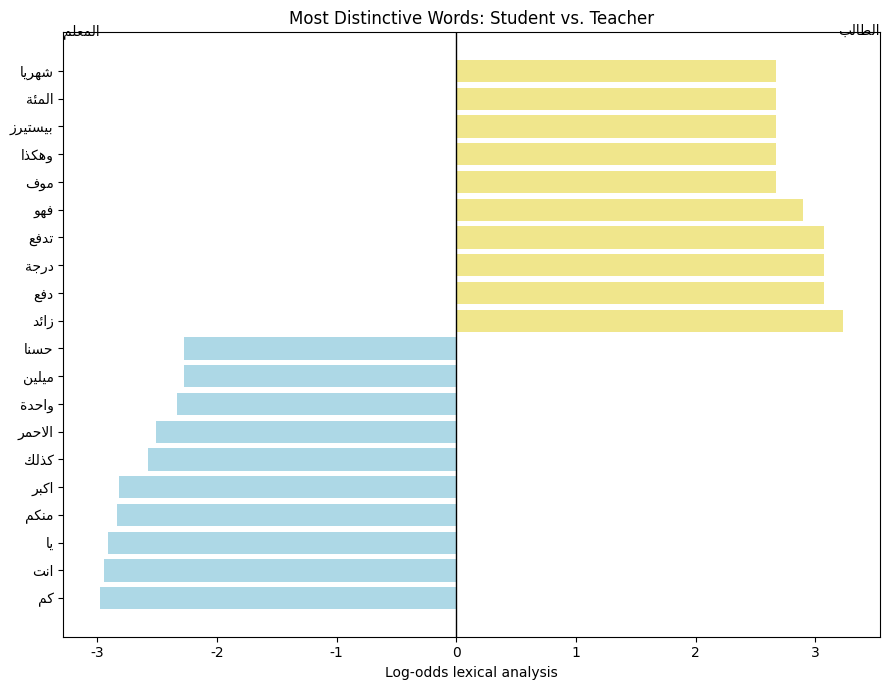


4) TEMPORAL ANALYSIS


(نسبة الكلام حسب الزمن المعلم مقابل الطالب)


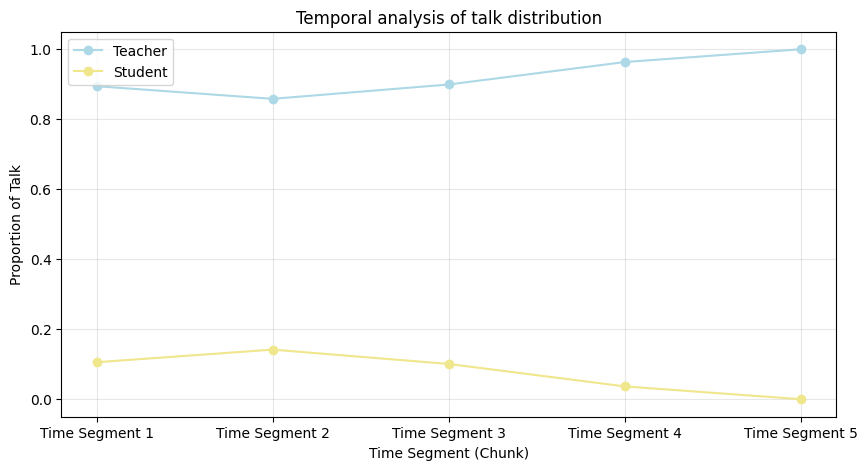

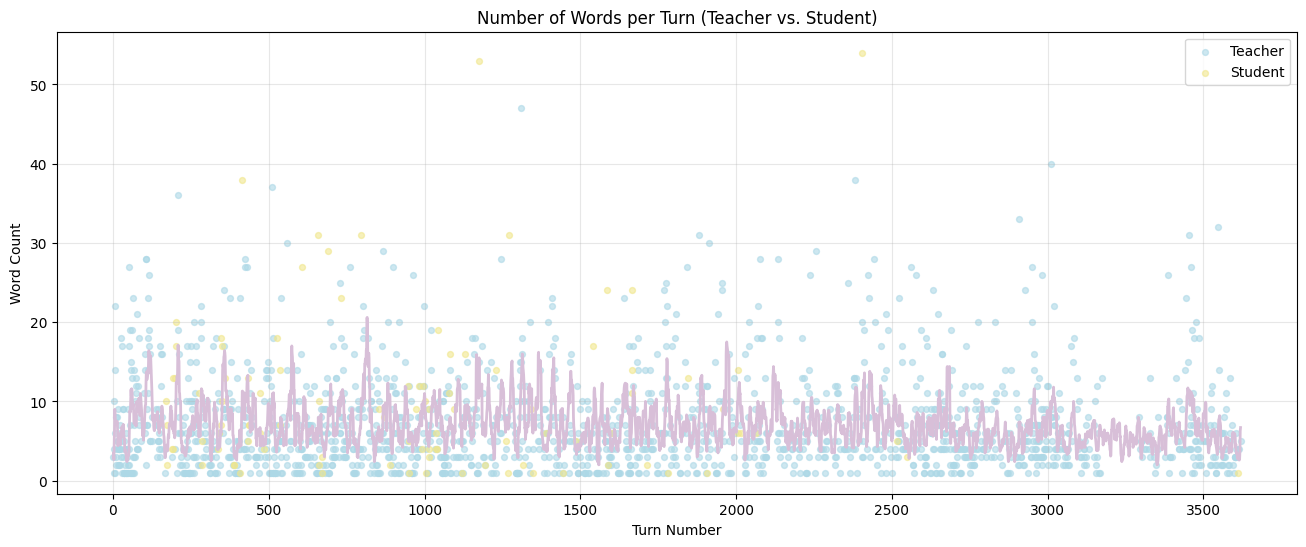

 مصفوفة انتقال حركات التحدث (أول صفوف):
لصفوف → الحركة السابقة
الأعمدة → الحركة التالية


,طلب توضيح,إعادة صياغة,توجيه,دعوة للمشاركة,تشجيع,سؤال تفسيري,تغذية راجعة
طلب توضيح,318,337,97,69,55,54,2
إعادة صياغة,335,705,202,125,87,63,7
توجيه,88,211,70,29,29,17,3
دعوة للمشاركة,81,115,23,35,14,23,2
تشجيع,46,91,23,24,18,13,0



5) GPT CONVERSATION ANALYSIS (تحليل المحادثة باستخدام GPT)

Extractive Conversation Summary:

1. اذا شققت واحدة من هذه الي نصفين ولديك ثلاث منها هناك فسوف تصنع، ستصنع ستة، وعلي اي حال، وعندما تشقينها الي نصفين في المنتصف هناك يكون الامر يشبه ذلك، يشبه هذا، كان هناك هذا، هذا كان الثلث الواحد [يشير الي القضيب البنفسجي] وهذا كان النصف الواحد [يشير الي القضيب الاخضر الداكن] في الاسفل، ولذلك فهو مثل هذا، والاحمر الذي اتظاهر به هو، هو، مثل نصف واحدة من البنفسجيات، وترين عندما شققته الي نصفين، انه، انه سدس، و، و انه يساوي، ويعادل اللون الاخضر
2. حسنا، اذن، انه مثل ذلك، يساعدنا فقط علي فهم ما نتحدث عنه مع قضبان كوزينير عندما نستخدم صناديق ذات احجام مختلفة لصنع احجام مختلفة، انصاف وارباع، ولكن، في الاساس يمكنك تسميتها بنفس الشيء كما تفعل حينها فقط الصغير مع الصغير فاذا سميتم الصندوق "كلا"، وسميتم القارب "نصفا"، فسيعادل ذلك "ربعا"
3. اعتقد انه علي حق، لانه يعرف ان هناك 9 كوبات في الاجمال، و لكل كوب من الكريم، هناك 2 شوكولاتة، لذا اولا يضيفهم و هناك 3 فقط، ولكن بعد ذلك الشيء كله هو 9، لذا هو يعت

In [ ]:
# ============================================================
# RUN: Upload ANY file (CSV / Excel / JSON / TXT)
# ============================================================

from google.colab import files

print("Please upload your data file (CSV, xlsx, etc.)")

uploaded = files.upload()
if len(uploaded) == 0:
    raise FileNotFoundError("No file was uploaded.")

FILE_PATH = list(uploaded.keys())[0]

print(f"Loaded file: {FILE_PATH}")

# Run the pipeline
results = run_pipeline_arabic(FILE_PATH, text_col=TEXT_COL)

print("✅ Pipeline completed successfully!")

In [ ]:
df = results["df"]

df[["text", "talk_move", "talk_move_score", "sentiment", "sentiment_score"]].head(10)


,text,talk_move,talk_move_score,sentiment,sentiment_score
0,هذا هو سؤالي,طلب توضيح,0.897578,neutral,0.816752
1,أليس هذا ما قلت؟,طلب توضيح,0.663223,neutral,0.627554
2,مايكل؟,طلب توضيح,0.407949,neutral,0.489383
3,إذا سميتُ البني واحدًا، فما الاسم العددي الذي ...,طلب توضيح,0.505724,neutral,0.697294
4,[يتوقف ثم يكرر السؤال] إذا سميتُ البني واحدًا،...,إعادة صياغة,0.545169,neutral,0.712132
5,[ينتظر الطلاب ليحلّوه ويرفعوا أيديهم] إذا سميت...,طلب توضيح,0.476846,neutral,0.637084
6,دانييل.,إعادة صياغة,0.437811,neutral,0.519764
7,لا أستطيع، جوانا، هل يمكنكِ، دانييل.,توجيه,0.338982,negative,0.484599
8,ألفِقوا لي مسألة.,دعوة للمشاركة,0.386015,negative,0.524956
9,أريد مسألة واحدة فقط لتأليفها، سنمرّ ونسمع مسا...,دعوة للمشاركة,0.663272,neutral,0.624642


In [ ]:
df["talk_move_score"].describe()

,talk_move_score
count,3619.000000
mean,0.470979
std,0.165849
min,0.170362
25%,0.348555
50%,0.427506
75%,0.562526
max,0.991878


In [ ]:

df["sentiment_score"].describe()


,sentiment_score
count,3619.000000
mean,0.629099
std,0.134522
min,0.344286
25%,0.519534
50%,0.619800
75%,0.733994
max,0.949443


In [ ]:
df[df["talk_move_score"] < 0.35][["text", "talk_move", "talk_move_score"]].head(10)


,text,talk_move,talk_move_score
7,لا أستطيع، جوانا، هل يمكنكِ، دانييل.,توجيه,0.338982
14,وأنتِ أليسا,إعادة صياغة,0.265415
15,أليسا، هلا قرأت لنا ذلك؟,سؤال تفسيري,0.314342
19,لقد أكلت ثلاثة، صحيح؟,طلب توضيح,0.278002
23,رد آخر,إعادة صياغة,0.336526
30,لقد كانوا مستعدين,إعادة صياغة,0.252867
31,سنبحث عن المشكلة الأولى التي كانت في تقييم الحلوى,طلب توضيح,0.349823
33,تمام,توجيه,0.302923
36,حسنًا؟,إعادة صياغة,0.311688
38,ليس هناك أيدي بعد,توجيه,0.259146


<H1> 3) Second method :</H1>
<H2>3.1) arabert :</H2>



In [ ]:

!pip install transformers accelerate -q


In [ ]:

import pandas as pd
import numpy as np
import re
import torch
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:

print("Upload your excel file : ")
uploaded = files.upload()

file_name = None
for fn in uploaded.keys():
    # قبول CSV
    if fn.endswith(".csv"):
        file_name = fn
        file_type = "csv"
        break
    # قبول Excel
    elif fn.endswith(".xlsx") or fn.endswith(".xls"):
        file_name = fn
        file_type = "excel"
        break

if file_name is None:
    raise ValueError("Please upload a CSV or Excel file.")

print(f" Uploaded file: {file_name}")

# قراءة الملف حسب النوع
if file_type == "csv":
    df = pd.read_csv(file_name)
else:
    df = pd.read_excel(file_name)

df.columns = df.columns.str.strip()

print("\n Columns found:")
print(df.columns)

print(" القيم الموجودة في عمود 'المتحدث':")
print(df["المتحدث"].unique())



Upload your excel file : 


Saving sharing dataset file.csv to sharing dataset file.csv
 Uploaded file: sharing dataset file.csv

 Columns found:
Index(['الطابع الزمني', 'الدور', 'المتحدث', 'الجملة', 'علامة المعلم',
       'علامة الطالب'],
      dtype='object')
 القيم الموجودة في عمود 'المتحدث':
['م' 'سيسيليو ديماس' 'ت/ر١' 'إريك' 'مايكل' 'دانييل' 'آلان' 'جيف' 'م٢ '
 'كيفن' 'ط' 'أندرو' 'ميريديث' 'ديفيد' 'طالب' 'برايان' 'جيسيكا' 'ط ط '
 'صموئيل' 'س ن' 'بيث' 'ميشيل' 'أليسا' 'شريك' 'جاكي' 'سينثيا' 'أوسي'
 'ميلين' 'ساوراب' 'ليندا فيشر' 'لورا' 'دانيال' 'كلير' 'أشانك' 'جاكلين'
 'شارلوت' 'م ٢ ' 'ستيفاني' 'طالب 1' 'آمي' 'ستيفاني وجيف' 'الآنسة ليو'
 'غريغوري' 'ديبورا' 'غراهام' 'أودرا' 'جايك' 'طلاب' 'تيموثي'
 'ميريديث وديفيد' 'سي' 'جيسون' 'مارك' 'ميشيل وميلين' 'كيلي'
 'جيسيكا وأودرا' 'آخرون' nan 'بلوند' 'ميلين،' '~23' 'الجميع' 'ميشيل وجيف'
 'ر٢' 'إريك وبريان']


In [ ]:
# ============================================
# 3) فلترة الطلاب — الإصدار الصحيح والمعتمد أكاديمياً
# ============================================

import re

sentence_col = "الجملة"
student_tag_col = "علامة الطالب"

# ✔ نعتبر كل سطر فيه علامة طالب = سطر لطالب
df_student = df[df[student_tag_col].notna()].copy()

print("\n عدد جمل الطلاب:", df_student.shape[0])
print(" أمثلة للعلامات:", df_student[student_tag_col].unique()[:20])

# ✔ إزالة الصفوف التي لا تحتوي على نص أو علامة
df_student = df_student.dropna(subset=[sentence_col, student_tag_col])


# ============================================
# 4) تنظيف العلامات
# ============================================
def clean_tag(text):
    if pd.isna(text):
        return "لا يوجد"

    text = str(text).strip()
    text = re.sub(r"^\s*\d+\s*[-–]?\s*", "", text)
    text = re.sub(r"^[-–]\s*", "", text)
    text = text.replace(" / ", "/").replace(" /", "/").replace("/ ", "/")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


# ============================================
# 5) تنظيف الجمل العربية
# ============================================
def clean_arabic_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # إزالة التشكيل
    text = re.sub(r'[\u064B-\u0652]', '', text)

    # إزالة التطويل
    text = re.sub(r'ـ+', '', text)

    # توحيد الحروف
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'ة', 'ه', text)

    # إزالة الرموز
    text = re.sub(r'[^\w\s]', ' ', text)

    # إزالة تكرار الحرف
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # إزالة المسافات المتكررة
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# تطبيق تنظيف العلامات
df_student[student_tag_col] = df_student[student_tag_col].apply(clean_tag)

# تطبيق تنظيف الجمل العربية (مهم جداً قبل التدريب!)
df_student[sentence_col] = df_student[sentence_col].apply(clean_arabic_text)

print("\n قيم علامة الطالب بعد التنظيف:")
print(df_student[student_tag_col].value_counts())



 عدد جمل الطلاب: 1498
 أمثلة للعلامات: ['1 - لا شيء' '4 - تقديم ادعاء' '5 - تقديم دليل / شرح الأسباب'
 '2 - الربط بفكرة طالب آخر' '3 - طلب المزيد من المعلومات'
 '3 - طلب معلومات']

 قيم علامة الطالب بعد التنظيف:
علامة الطالب
لا شيء                     443
تقديم دليل/شرح الأسباب     421
تقديم ادعاء                336
الربط بفكرة طالب آخر       257
طلب المزيد من المعلومات     38
طلب معلومات                  3
Name: count, dtype: int64



📊 توزيع مستويات التفكير:
thinking_level
0    443
1    339
2    459
3    257
Name: count, dtype: int64

🟢 تدريب: 1198
🟡 اختبار: 300


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...


🚀 بدء تدريب AraBERT على جمل الطلاب...


Step,Training Loss
20,1.359200
40,1.345900
60,1.332100
80,1.255500
100,1.265100
120,1.277400
140,1.217100
160,1.220800
180,1.188800
200,1.035700



🎯 Accuracy: 0.5966666666666667

📊 Classification Report:
              precision    recall  f1-score   support

           0      0.625     0.769     0.690        78
           1      0.500     0.567     0.531        67
           2      0.781     0.588     0.671        97
           3      0.436     0.414     0.425        58

    accuracy                          0.597       300
   macro avg      0.586     0.584     0.579       300
weighted avg      0.611     0.597     0.597       300



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

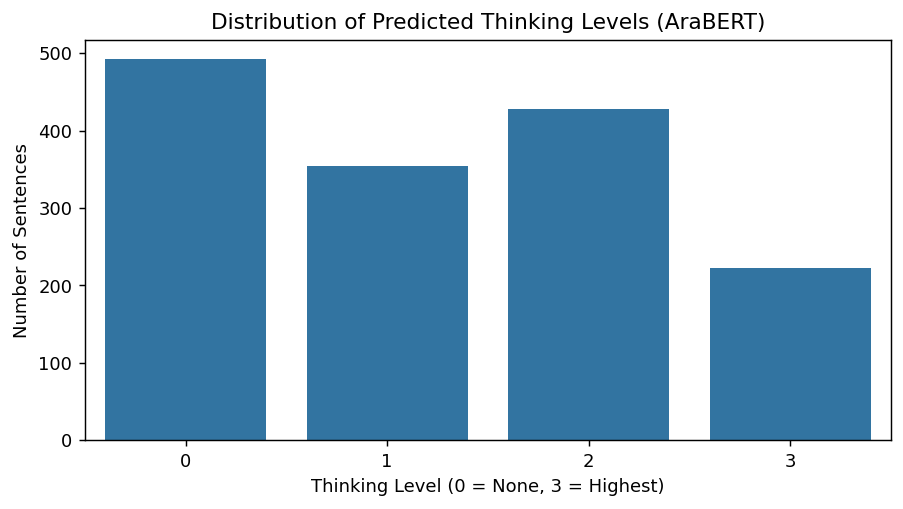

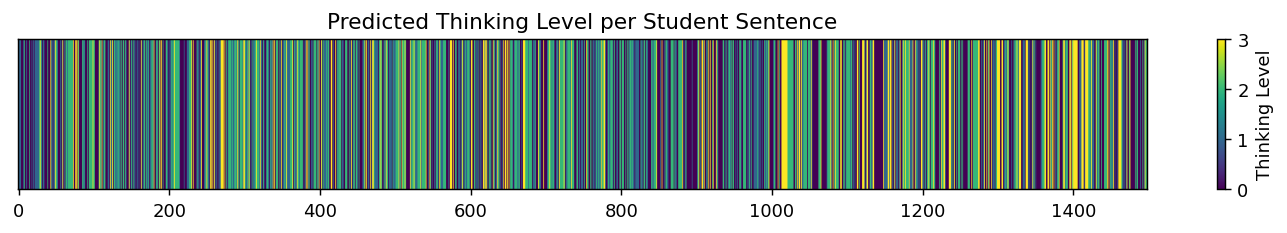


✅ جاهز — النموذج يعمل بكفاءة ويصدر التوقعات بدون أخطاء.


In [ ]:
# ============================================
# 5) تحويل العلامات إلى مستويات (0–3) — النسخة النهائية
# ============================================
import os
os.environ["WANDB_DISABLED"] = "true"
def map_to_level(tag):
    if pd.isna(tag):
        return 0

    t = clean_tag(tag)

    # Level 0
    if t == "لا شيء":
        return 0

    # Level 1
    if t in ["تقديم ادعاء", "طلب معلومات"]:
        return 1

    # Level 2
    if t in ["تقديم دليل/شرح الأسباب", "طلب المزيد من المعلومات"]:
        return 2

    # Level 3
    if t == "الربط بفكرة طالب آخر":
        return 3

    return 0


df_student["thinking_level"] = df_student[student_tag_col].apply(map_to_level)

# الشرح
explain_levels = {
    0: "لا يوجد تفكير استدلالي واضح",
    1: "ادعاء فقط بدون أدلة",
    2: "تفكير متوسط: تقديم دليل أو شرح أسباب",
    3: "تفكير أعلى: الربط أو طلب معلومات"
}

df_student["التفسير"] = df_student["thinking_level"].apply(lambda x: explain_levels[x])

print("\n توزيع مستويات التفكير:")
print(df_student["thinking_level"].value_counts().sort_index())


# ============================================
# 6) تجهيز بيانات التدريب
# ============================================
texts = df_student[sentence_col].astype(str).tolist()
labels = df_student["thinking_level"].astype(int).tolist()

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

print(f"\n تدريب: {len(X_train)}")
print(f" اختبار: {len(X_test)}")


# ============================================
# 7) تحميل AraBERT
# ============================================
model_name = "aubmindlab/bert-base-arabertv02"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=4
).to(device)


# ============================================
# 8) Dataset
# ============================================
class ArabicReasoningDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding=False,
            max_length=self.max_length,
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = ArabicReasoningDataset(X_train, y_train, tokenizer)
test_dataset  = ArabicReasoningDataset(X_test,  y_test,  tokenizer)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# ============================================
# 9) Trainer
# ============================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}


training_args = TrainingArguments(
    output_dir="./arabert_reasoning",
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=20,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)



# ============================================
# 10) التدريب
# ============================================
print("\nبدء تدريب AraBERT على جمل الطلاب...")
trainer.train()



# ============================================
# 11) التقييم
# ============================================
eval_output = trainer.evaluate()
print("\n Accuracy:", eval_output["eval_accuracy"])

preds_logits = trainer.predict(test_dataset).predictions
preds = np.argmax(preds_logits, axis=-1)

print("\n Classification Report:")
print(classification_report(y_test, preds, digits=3))



# ============================================
# 12) التوقع لكل جملة طالب (Batching)
# ============================================
df_student[sentence_col] = df_student[sentence_col].astype(str)

def predict_levels(text_list, batch_size=16):
    all_preds = []
    model.eval()
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        enc = tokenizer(
            batch, truncation=True, padding=True, max_length=128,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            logits = model(**enc).logits
        all_preds.extend(np.argmax(logits.cpu(), axis=-1).tolist())
    return all_preds


df_student["pred_thinking_level"] = predict_levels(df_student[sentence_col].tolist())
df_student["pred_التفسير"] = df_student["pred_thinking_level"].apply(lambda x: explain_levels[x])


# ============================================
# 13) حفظ النتائج
# ============================================
out_name = "students_reasoning_arabert.xlsx"
df_student.to_excel(out_name, index=False)
files.download(out_name)



# ============================================
# 14) الرسومات
# ============================================

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130


# Histogram / Bar Plot
plt.figure(figsize=(8,4))
sns.countplot(x=df_student["pred_thinking_level"])
plt.title("Distribution of Predicted Thinking Levels (AraBERT)")
plt.xlabel("Thinking Level (0 = None, 3 = Highest)")
plt.ylabel("Number of Sentences")
plt.show()


# Heatmap Strip
plt.figure(figsize=(14, 1.5))
plt.imshow(df_student["pred_thinking_level"].values[np.newaxis, :],
           aspect="auto", cmap="viridis")
plt.yticks([])
plt.colorbar(label="Thinking Level")
plt.title("Predicted Thinking Level per Student Sentence")
plt.show()


print("\n جاهز — النموذج يعمل بكفاءة ويصدر التوقعات بدون أخطاء.")


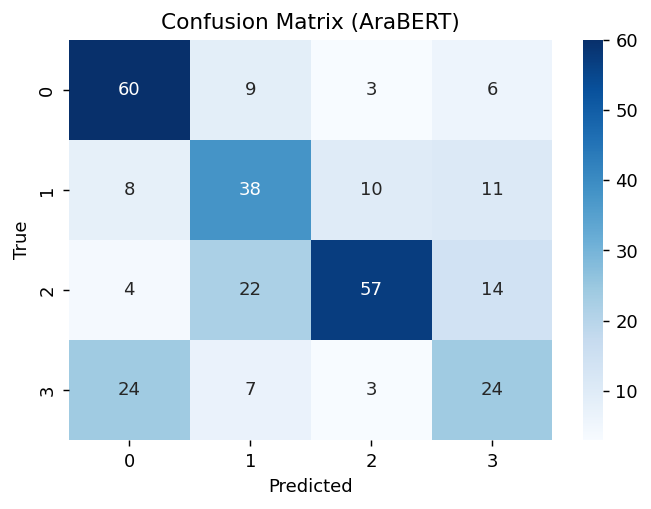

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["0","1","2","3"],
            yticklabels=["0","1","2","3"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (AraBERT)")
plt.show()


<Figure size 1040x520 with 0 Axes>

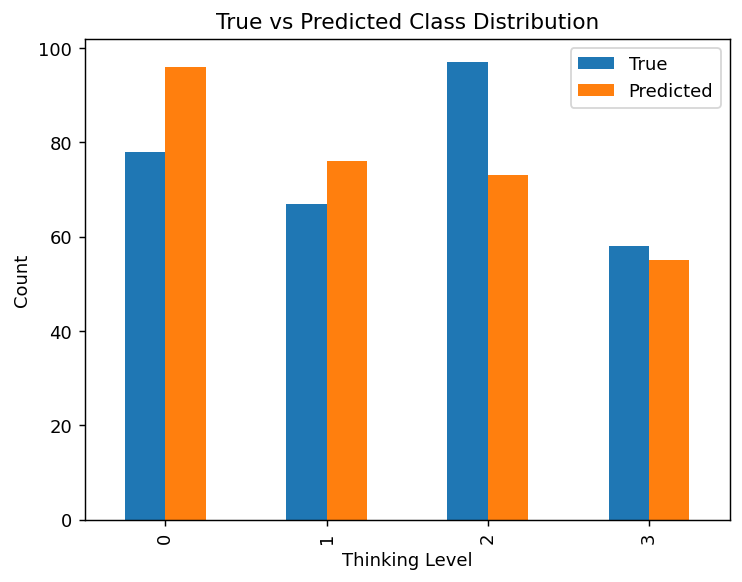

In [ ]:
plt.figure(figsize=(8,4))
true_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(preds).value_counts().sort_index()

df_compare = pd.DataFrame({
    "True": true_counts,
    "Predicted": pred_counts
})

df_compare.plot(kind="bar")
plt.title("True vs Predicted Class Distribution")
plt.xlabel("Thinking Level")
plt.ylabel("Count")
plt.show()


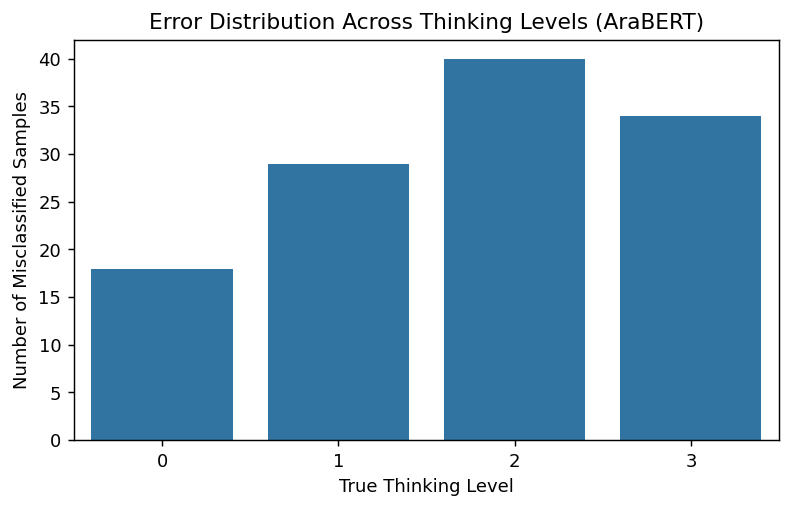

In [ ]:
# ============================================
# Error Distribution Plot
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

errors = (preds != np.array(y_test))
error_levels = np.array(y_test)[errors]

plt.figure(figsize=(7,4))
sns.countplot(x=error_levels)
plt.title("Error Distribution Across Thinking Levels (AraBERT)")
plt.xlabel("True Thinking Level")
plt.ylabel("Number of Misclassified Samples")
plt.show()


In [ ]:
# ============================================
# Misclassified Examples Table
# ============================================

misclassified = []

for text, true, pred in zip(X_test, y_test, preds):
    if true != pred:
        misclassified.append([text, true, pred])

mis_df = pd.DataFrame(misclassified, columns=["Sentence", "True Level", "Predicted Level"])

print("\n أول 20 مثال من الجمل التي أخطأ فيها النموذج:")
mis_df.head(20)



🔍 أول 20 مثال من الجمل التي أخطأ فيها النموذج:


,Sentence,True Level,Predicted Level
0,كانت تفعل فقط,3,0
1,لقد وضع مثل,3,0
2,4 2,2,1
3,سيكون هذا نصف القضيب البرتقالي يشير الي قضيب ا...,2,1
4,64,2,1
5,انت لا تقيس نفس الشيء,1,3
6,ولكن اذا كان علي الاطلاق اذا كان قد فعل ذلك لو...,2,3
7,ماذا لديك,3,0
8,يجب ان يكون هناك واحد,0,1
9,وبعدها استمر في القيام بذلك ولكن بعد ذلك استمر,2,3


# AraELECTRA

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

model_electra_name = "aubmindlab/araelectra-base-discriminator"

tokenizer_electra = AutoTokenizer.from_pretrained(model_electra_name)

model_electra = AutoModelForSequenceClassification.from_pretrained(
    model_electra_name,
    num_labels=4
).to(device)

training_args_electra = TrainingArguments(
    output_dir="./results_araelectra",
    num_train_epochs=4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=20,
    report_to="none",
    save_strategy="no"
)

trainer_electra = Trainer(
    model=model_electra,
    args=training_args_electra,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer_electra,
    compute_metrics=compute_metrics,
)

print("\n Starting AraELECTRA training...")
trainer_electra.train()


tokenizer_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at aubmindlab/araelectra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4087210016.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_electra = Trainer(



🚀 Starting AraELECTRA training...


Step,Training Loss
20,1.370600
40,1.357800
60,1.295300
80,1.277600
100,1.206800
120,1.201500
140,1.173600
160,1.154800
180,1.143900
200,1.037500


TrainOutput(global_step=1200, training_loss=0.8233968011538187, metrics={'train_runtime': 91.9746, 'train_samples_per_second': 52.101, 'train_steps_per_second': 13.047, 'total_flos': 51254131725888.0, 'train_loss': 0.8233968011538187, 'epoch': 4.0})

In [ ]:
eval_output_electra = trainer_electra.evaluate()
print("\n AraELECTRA Accuracy:", eval_output_electra["eval_accuracy"])



🎯 AraELECTRA Accuracy: 0.5866666666666667


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

preds_logits_electra = trainer_electra.predict(test_dataset).predictions
preds_electra = np.argmax(preds_logits_electra, axis=-1)

print("\n AraELECTRA Classification Report:")
print(classification_report(y_test, preds_electra, digits=3))



📊 AraELECTRA Classification Report:
              precision    recall  f1-score   support

           0      0.600     0.769     0.674        78
           1      0.474     0.552     0.510        67
           2      0.730     0.670     0.699        97
           3      0.424     0.241     0.308        58

    accuracy                          0.587       300
   macro avg      0.557     0.558     0.548       300
weighted avg      0.580     0.587     0.575       300



<H2>3.2) code araelectra :</H2>

✅ Device: cuda
📂 Upload your dataset file:


Saving sharing dataset file.csv to sharing dataset file.csv
✔ Using file: sharing dataset file.csv

📌 Columns found:
Index(['الطابع الزمني', 'الدور', 'المتحدث', 'الجملة', 'علامة المعلم',
       'علامة الطالب'],
      dtype='object')

🔵 Student sentences: 1498
🧪 Sample tags: ['1 - لا شيء' '4 - تقديم ادعاء' '5 - تقديم دليل / شرح الأسباب'
 '2 - الربط بفكرة طالب آخر' '3 - طلب المزيد من المعلومات'
 '3 - طلب معلومات']

📊 Thinking Level Distribution:
thinking_level
0    484
1    336
2    421
3    257
Name: count, dtype: int64

🟢 Train: 1198
🟡 Test : 300


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at aubmindlab/araelectra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2589844848.py:182: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



🚀 Training AraELECTRA...


Step,Training Loss
20,1.391300
40,1.357800
60,1.298400
80,1.336400
100,1.172700
120,1.253500
140,1.211500
160,1.224100
180,1.224900
200,1.144700



🎯 AraELECTRA Accuracy: 0.6466666666666666

📊 Classification Report:
              precision    recall  f1-score   support

           0      0.747     0.701     0.723        97
           1      0.635     0.597     0.615        67
           2      0.708     0.750     0.728        84
           3      0.404     0.442     0.422        52

    accuracy                          0.647       300
   macro avg      0.623     0.623     0.622       300
weighted avg      0.652     0.647     0.648       300



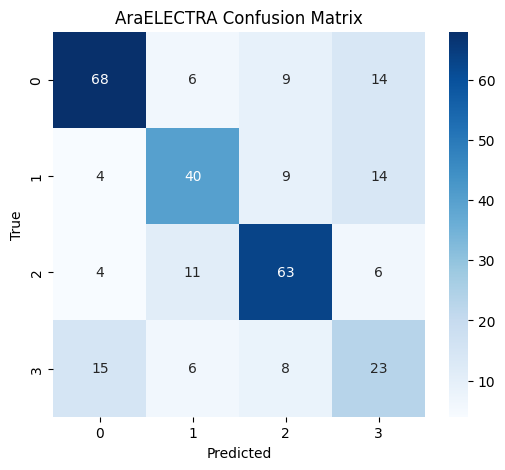

In [ ]:
# ============================================
# 0) Install Libraries
# ============================================
!pip install transformers accelerate -q

# ============================================
# 1) Imports
# ============================================
import pandas as pd
import numpy as np
import re
import torch
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================
# 2) Upload Dataset (CSV or Excel)
# ============================================
print(" Upload your dataset file:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print("✔ Using file:", file_name)

if file_name.endswith(".csv"):
    df = pd.read_csv(file_name)
elif file_name.endswith(".xlsx"):
    df = pd.read_excel(file_name)
else:
    raise ValueError("Unsupported file format")

df.columns = df.columns.str.strip()
print("\n Columns found:")
print(df.columns)

# ============================================
# 3) Student Filtering (Tag-based – Academic)
# ============================================
sentence_col = "الجملة"
student_tag_col = "علامة الطالب"

df_student = df[df[student_tag_col].notna()].copy()

df_student = df_student.dropna(subset=[sentence_col, student_tag_col])

print("\n Student sentences:", len(df_student))
print(" Sample tags:", df_student[student_tag_col].unique()[:10])

# ============================================
# 4) Cleaning Tags + Arabic Text
# ============================================
def clean_tag(text):
    if pd.isna(text):
        return "لا شيء"
    text = str(text).strip()
    text = re.sub(r"^\d+\s*[-–]?\s*", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

def clean_arabic_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'[\u064B-\u0652]', '', text)
    text = re.sub(r'ـ+', '', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_student[student_tag_col] = df_student[student_tag_col].apply(clean_tag)
df_student[sentence_col] = df_student[sentence_col].apply(clean_arabic_text)

# ============================================
# 5) Map Tags → Thinking Levels
# ============================================
def map_to_level(tag):
    if tag == "لا شيء":
        return 0
    if tag == "تقديم ادعاء":
        return 1
    if tag == "تقديم دليل / شرح الأسباب":
        return 2
    if tag == "الربط بفكرة طالب آخر":
        return 3
    return 0

df_student["thinking_level"] = df_student[student_tag_col].apply(map_to_level)

print("\n Thinking Level Distribution:")
print(df_student["thinking_level"].value_counts().sort_index())

# ============================================
# 6) Train / Test Split
# ============================================
texts = df_student[sentence_col].tolist()
labels = df_student["thinking_level"].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\n Train: {len(X_train)}")
print(f" Test : {len(X_test)}")

# ============================================
# 7) Load AraELECTRA
# ============================================
model_name = "aubmindlab/araelectra-base-discriminator"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=4
).to(device)

# ============================================
# 8) Dataset Class
# ============================================
class ArabicDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding=False,
            max_length=self.max_len
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = ArabicDataset(X_train, y_train, tokenizer)
test_dataset  = ArabicDataset(X_test,  y_test,  tokenizer)
data_collator = DataCollatorWithPadding(tokenizer)

# ============================================
# 9) Trainer
# ============================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir="./araelectra_results",
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-5,
    logging_steps=20,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# ============================================
# 10) Train
# ============================================
print("\n Training AraELECTRA...")
trainer.train()

# ============================================
# 11) Evaluation
# ============================================
eval_output = trainer.evaluate()
print("\n AraELECTRA Accuracy:", eval_output["eval_accuracy"])

preds = np.argmax(trainer.predict(test_dataset).predictions, axis=1)

print("\n Classification Report:")
print(classification_report(y_test, preds, digits=3))

# ============================================
# 12) Confusion Matrix
# ============================================
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("AraELECTRA Confusion Matrix")
plt.show()


In [ ]:
# ============================================
# Misclassified Examples Table
# ============================================

misclassified = []

for text, true, pred in zip(X_test, y_test, preds):
    if true != pred:
        misclassified.append([text, true, pred])

mis_df = pd.DataFrame(misclassified, columns=["Sentence", "True Level", "Predicted Level"])

print("\n أول 20 مثال من الجمل التي أخطأ فيها النموذج:")
mis_df.head(20)


🔍 أول 20 مثال من الجمل التي أخطأ فيها النموذج:


,Sentence,True Level,Predicted Level
0,ويقول اونلاين فليكس و ميل فلكس و,2,1
1,وهذا هو ثلث,0,1
2,نعم تري اذا اذا كان لديك لجعل ابراج من واحد وه...,1,2
3,اعتقد ان هذا منطقي رياضيا لكن اعتقد ان هناك شي...,2,1
4,انها طريقه مختلفه,2,3
5,نعم مممم همممم,3,0
6,كم عدد الابراج التي يمكنكم صنعها,3,1
7,اسماء الالوان لا,0,3
8,لانه اذا كان هذا واحدا يرفع قضيبا احمر,1,2
9,نعم ميشيل لماذا فعلت,3,0


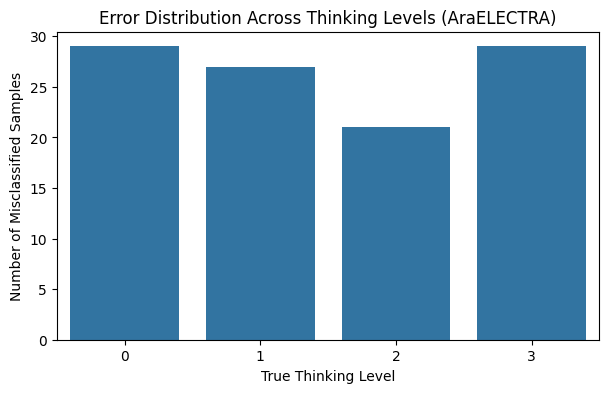

In [ ]:
# ============================================
# Error Distribution Plot
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

errors = (preds != np.array(y_test))
error_levels = np.array(y_test)[errors]

plt.figure(figsize=(7,4))
sns.countplot(x=error_levels)
plt.title("Error Distribution Across Thinking Levels (AraELECTRA)")
plt.xlabel("True Thinking Level")
plt.ylabel("Number of Misclassified Samples")
plt.show()
